In [2]:
import numpy as np
import matplotlib.pyplot as plt

rng=np.random.default_rng(3071) #On va utiliser une seed fixe pour pouvoir reproduire les résultats

# Question 1

## 1.3

[]


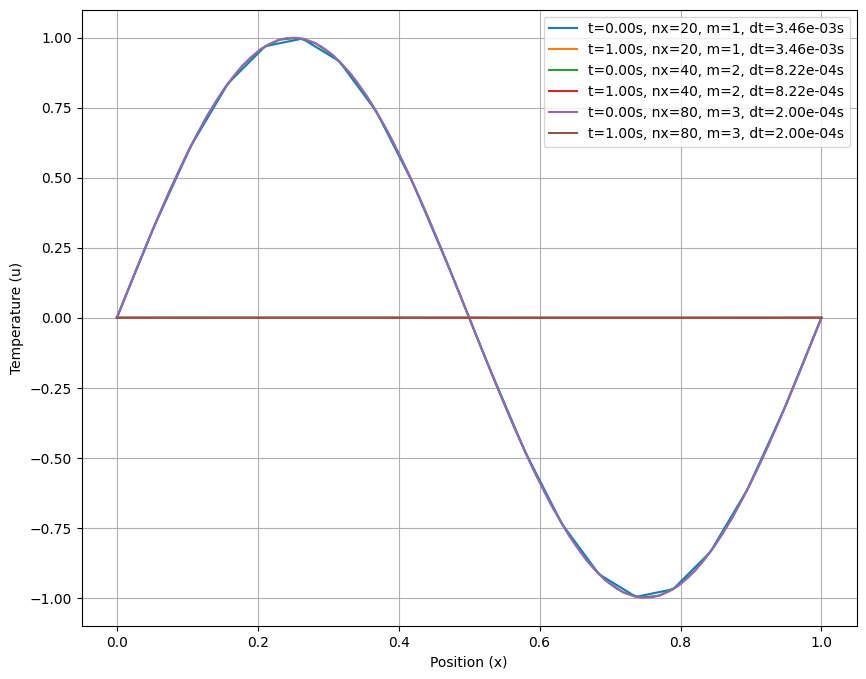

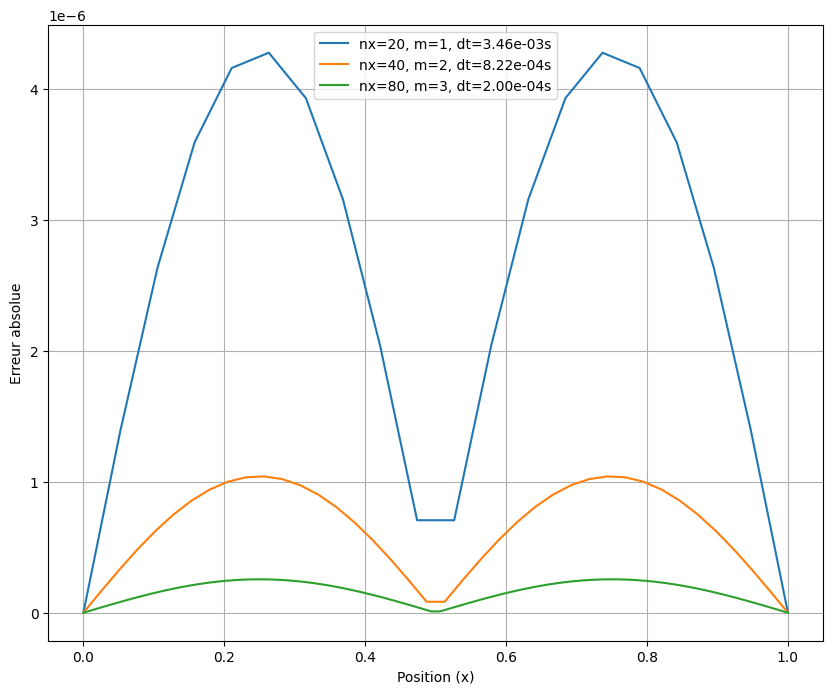

In [11]:
def chaleur_theorique(b,tf,nx, dt, k, alpha):
    x = np.linspace(0, b, nx)
    t=np.linspace(0, tf, int(np.ceil(tf/dt)) + 1)
    u_theorique = np.zeros((len(t), nx))
    for i in range(len(t)):
        u_theorique[i, :] = np.exp(-alpha * (k * np.pi)**2 * t[i]) * np.sin(k * np.pi * x)
    return u_theorique

def chaleur_1d(u0, L, T, nx, dt, dx, alpha):
    nx_compteur=0
    nt = int(np.ceil(T / dt))
    t=np.linspace(0, T, nt+1)
    u = np.zeros((nt+1, nx))
    u[0, :] = u0
    for n in range(nt):     
        for i in range(1, nx-1):
            u[n + 1, i] = u[n, i] + alpha * dt / dx**2 * (u[n, i + 1] - 2 * u[n, i] + u[n, i - 1])
        u[n + 1, 0] = 0
        u[n + 1, -1] = 0
            
    
    return u


k=2
kappa=0.2
b=1.0
tf=1
u0 = lambda x: np.sin(k * np.pi * x)
m=np.array([1,2,3])
nx=10*2**m
dx = b/(nx-1)
dt=0.25*dx**2/kappa
alpha=kappa*dt/dx**2

u=[]
nx_E_liste=[]

u=[chaleur_1d(u0(np.linspace(0, b, n)), b, tf, n, dt[i], dx[i], alpha[0]) for i,n in enumerate(nx)]
u_theorique=[chaleur_theorique(b,tf,n, dt[i], k, alpha[0]) for i, n in enumerate(nx)]

print(nx_E_liste)

plt.figure(figsize=(10, 8))
for i, n in enumerate(nx):
    plt.plot(np.linspace(0, b, n), u[i][0, :], label=f't={0:.2f}s, nx={n}, m={m[i]}, dt={dt[i]:.2e}s')
    plt.plot(np.linspace(0, b, n), u[i][-1, :], label=f't={tf:.2f}s, nx={n}, m={m[i]}, dt={dt[i]:.2e}s')
plt.xlabel('Position (x)')
plt.ylabel('Temperature (u)')
plt.legend()
plt.grid(which='both')
plt.savefig('chaleur_1d.png')

plt.figure(figsize=(10, 8))
for i,n in enumerate(nx):
    x = np.linspace(0, b, n)
    erreur = np.abs(u[i][-1, :] - u_theorique[i][-1, :])
    plt.plot(x, erreur, label=f'nx={n}, m={m[i]}, dt={dt[i]:.2e}s')
plt.xlabel('Position (x)')
plt.ylabel('Erreur absolue')
plt.legend()
plt.grid(which='both')
plt.savefig('erreur_chaleur_1d.png')
plt.show()




## 1.4

 ### 1.

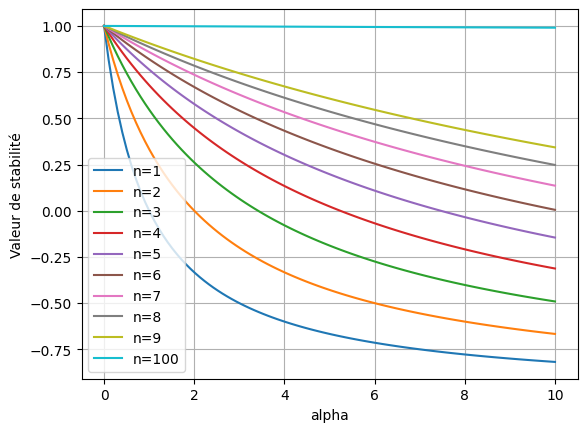

In [46]:
def Crank_Nicolson_stabilité(alpha, l,n): #l est la longueur de la barre, n est un vecteur propre spécifique
    theta = l*np.pi/(n+1) 
    num=2-alpha*(2-2*np.cos(theta))
    denom=2+alpha*(2-2*np.cos(theta))
    return num/denom

l=1.0
n=np.arange(1, 10) #On teste sur les 99 premiers vecteurs propres
n=np.append(n, 100) #On ajoute le 100ème vecteur propre pour voir ce qui se passe à des valeurs plus élevées de n
alpha=np.linspace(1e-5, 10,100) #On teste sur des valeurs de alpha allant de 0 à 10

stabilité=np.zeros((len(alpha), len(n)))
for i,N in enumerate(n):
    for j,a in enumerate(alpha):
        stab=Crank_Nicolson_stabilité(a, l,N)
        if stab >= 1:
            print(f'Instabilité détectée pour n={N} et alpha={a:.2f} avec une valeur de stabilité de {stab:.2f}')
        else:
            stabilité[j,i]=stab
        
    plt.plot(alpha, stabilité[:,i], label=f'n={N}')

plt.xlabel('alpha')
plt.ylabel('Valeur de stabilité')
plt.legend()   
plt.grid(which="both") 
plt.savefig("Crank_Nicolson_stabilité.png")
plt.show()


### 2.

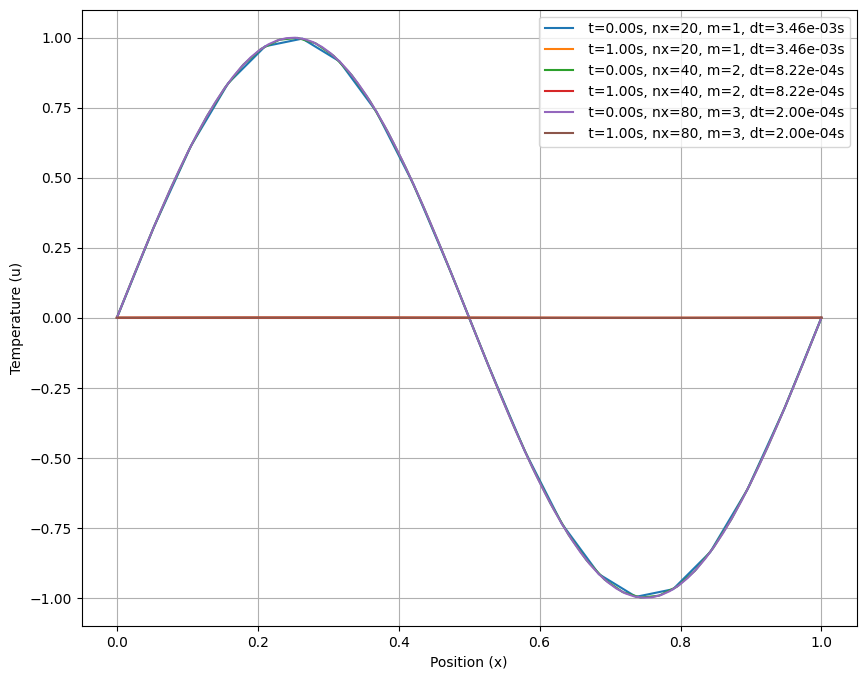

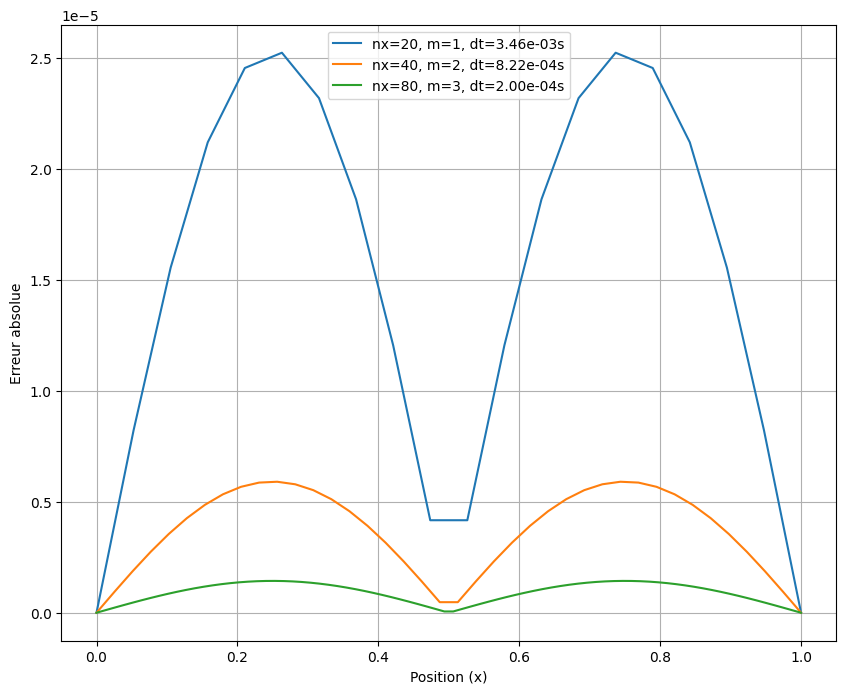

In [12]:
def Thomas_matrice(A, b):
    n = len(b)
    c_prime = np.zeros(n-1)
    d_prime = np.zeros(n)
    
    c_prime[0] = A[0, 1] / A[0, 0]
    d_prime[0] = b[0] / A[0, 0]
    
    for i in range(1, n-1):
        denom = A[i, i] - A[i, i-1] * c_prime[i-1]
        c_prime[i] = A[i, i+1] / denom
        d_prime[i] = (b[i] - A[i, i-1] * d_prime[i-1]) / denom
    
    d_prime[n-1] = (b[n-1] - A[n-1, n-2] * d_prime[n-2]) / (A[n-1, n-1] - A[n-1, n-2] * c_prime[n-2])
    
    x = np.zeros(n)
    x[-1] = d_prime[-1]
    
    for i in range(n-2, -1, -1):
        x[i] = d_prime[i] - c_prime[i] * x[i+1]
    
    return x

def Crank_Nicolson(u0, L, T, nx, dt, dx, alpha):
    nx_compteur=0
    nt = int(np.ceil(T / dt))
    t=np.linspace(0, T, nt+1)
    u = np.zeros((nt+1, nx))
    u[0, :] = u0
    A = np.zeros((nx-2, nx-2))
    for i in range(nx-2):
        nx_compteur+=1
        A[i, i] = 1 + alpha * dt / dx**2
        if i > 0:
            A[i, i-1] = -alpha * dt / (2 * dx**2)
        if i < nx-3:
            A[i, i+1] = -alpha * dt / (2 * dx**2)
    
    for n in range(nt):
        b = np.zeros(nx-2)
        for i in range(1, nx-1):
            nx_compteur+=1
            b[i-1] = (1 - alpha * dt / dx**2) * u[n, i] + (alpha * dt / (2 * dx**2)) * (u[n, i+1] + u[n, i-1])
        
        b[0] += alpha * dt / (2 * dx**2) * u[n, 0]
        b[-1] += alpha * dt / (2 * dx**2) * u[n, -1]
        
        u[n + 1, 1:-1] = Thomas_matrice(A, b) #On résout la partie implicite du système linéaire
        u[n + 1, 0] = 0
        u[n + 1, -1] = 0
    
    return u,nx_compteur
Compteur=0
k=2
kappa=0.2
b=1.0
tf=1
u0 = lambda x: np.sin(k*np.pi*x)
m=np.array([1,2,3])
nx=10*2**m
dx = b/(nx-1)
dt=0.25*dx**2/kappa

u_cn=[]
nx_cn_liste=[]

for i,n in enumerate(nx):
    u,nx_cn=Crank_Nicolson(u0(np.linspace(0, b, n)), b, tf, n, dt[i], dx[i], kappa)
    u_cn.append(u)
    nx_cn_liste.append(nx_cn)

u_theorique_cn=[chaleur_theorique(b,tf,n, dt[i], k, kappa) for i, n in enumerate(nx)]

plt.figure(figsize=(10, 8))
for i, n in enumerate(nx):
    plt.plot(np.linspace(0, b, n), u_cn[i][0, :], label=f' t={0:.2f}s, nx={n}, m={m[i]}, dt={dt[i]:.2e}s')
    plt.plot(np.linspace(0, b, n), u_cn[i][-1, :], label=f' t={tf:.2f}s, nx={n}, m={m[i]}, dt={dt[i]:.2e}s')
plt.xlabel('Position (x)')
plt.ylabel('Temperature (u)')
plt.legend()
plt.grid(which='both')
plt.savefig('chaleur_1d_crank_nicolson.png')

plt.figure(figsize=(10, 8))
for i,n in enumerate(nx):
    x = np.linspace(0, b, n)
    erreur = np.abs(u_cn[i][-1, :] - u_theorique_cn[i][-1, :])
    plt.plot(x, erreur, label=f'nx={n}, m={m[i]}, dt={dt[i]:.2e}s')
plt.xlabel('Position (x)')
plt.ylabel('Erreur absolue')
plt.legend()
plt.grid(which='both')
plt.savefig('erreur_chaleur_1d_crank_nicolson.png')

plt.show()




# Question 2

## 1. 

In [41]:
def MC_balistique(f,f_theo,params): #f est la fonction, params est une liste de la forme [a,b,N] où a et b sont les bornes de l'intervalle d'intégration et N est le nombre de points à générer
    a=params[0]
    b=params[1]
    N=params[2]

    Int_theo=f_theo(b)-f_theo(a)

    x_boite=np.linspace(a,b,N)
    y_boite=f(x_boite)

    M_haut=y_boite.max()

    if M_haut>0:
        M_haut*=1.05
        
    elif M_haut<0:
        M_haut*=0
    
    M_bas=y_boite.min()

    if M_bas>0:
        M_bas*=0

    elif M_bas<0:
        M_bas*=1.05

    err=100
    essai=0
    while err > 1:
        x=rng.uniform(a,b,N)
        y=rng.uniform(M_bas,M_haut,N)

        points_in_posi=(f(x)>=0) & (y>=0) & (y<f(x))#On récupère tous les points qui sont dans la région positive à intégrer
        points_in_néga=(f(x)<=0) & (y<=0) & (y>f(x))

        points_in=points_in_posi.astype(int)-points_in_néga.astype(int) #On récupère tous les points qui sont dans la région à intégrer, en prenant en compte les régions négatives

        I=(b-a)*(M_haut-M_bas)*np.sum(points_in)/N #L'intégrale est données par le pourcentage de points dans la région fois l'aire de la boîte)

        err=abs(1-(I/Int_theo))*100 #On calcule l'erreur en pourcentage
        essai+=1
    return I,err,essai

    

fonction = lambda x: np.exp(-3*x)*(np.sin(x)**3) #Fonction qui prend x en entrée et retourne la valeur de la fonction à ce point
f_theo=lambda x:np.exp(-3*x)*(-27*np.sin(x)+5*np.sin(3*x)-9*np.cos(x)+5*np.cos(3*x))/120

paramètres=[0,10,10000]
Int,yerr,essai=MC_balistique(fonction,f_theo,paramètres)

print("L'intégrale est =",Int)
print("L'erreur est =",yerr,"%")
print("Le nombre d'essais est =",essai)

L'intégrale est = 0.03325284143936836
L'erreur est = 0.24147568193709779 %
Le nombre d'essais est = 6


### Vérification

In [ ]:

#-----------On définit les bornes de la boîte------------------
def MC_ballistique(f,params): #f est la fonction, params est une liste de la forme [a,b,N] où a et b sont les bornes de l'intervalle d'intégration et N est le nombre de points à générer
    a=params[0]
    b=params[1]
    N=params[2]
    x_boite=np.linspace(a,b,N)
    y_boite=f(x_boite)
    
    M_haut=y_boite.max()

    if M_haut>0:
        M_haut*=1.05
        
    elif M_haut<0:
        M_haut*=0
    
    M_bas=y_boite.min()

    if M_bas>0:
        M_bas*=0

    elif M_bas<0:
        M_bas*=1.05
    x=rng.uniform(a,b,N)
    y=rng.uniform(M_bas,M_haut,N)
    points_in_posi=(f(x)>=0) & (y>=0) & (y<f(x))#On récupère tous les points qui sont dans la région positive à intégrer
    points_in_néga=(f(x)<=0) & (y<=0) & (y<f(x))
    points_in=points_in_posi.astype(int)-points_in_néga.astype(int) #On récupère tous les points qui sont dans la région à intégrer, en prenant en compte les régions négatives
    I=(b-a)*(M_haut-M_bas)*np.sum(points_in)/N #L'intégrale est données par le pourcentage de points dans la région fois l'aire de la boîte)
    return I

    
fonction = lambda x: x #On teste avec une fonction facile à intégrer: l'intégrale de y=x de 0 à 1 est égale à 0.5


paramètres=[0,1,100000]
Int=MC_ballistique(fonction,paramètres)
print(Int)

0.5017845000000001


## 2.

In [44]:
def Int_Moyenne_Pondérée(f,f_theo,params):
    a,b,N=params

    Int_theo=f_theo(b)-f_theo(a)

    err=100
    essai=0

    while err > 1:
        x=rng.uniform(a,b,N)
        y=f(x)
        Int=np.mean(y)*(b-a)
        err=abs(1-(Int/Int_theo))*100
        essai+=1
    return Int,err,essai

fonction = lambda x: np.exp(-3*x)*(np.sin(x)**3) #Fonction qui prend x en entrée et retourne la valeur de la fonction à ce point
f_theo=lambda x:np.exp(-3*x)*(-27*np.sin(x)+5*np.sin(3*x)-9*np.cos(x)+5*np.cos(3*x))/120

paramètres=[0,10,10000]
Int,yerr,essai=Int_Moyenne_Pondérée(fonction,f_theo,paramètres)

print("L'intégrale est =",Int)
print("L'erreur est =",yerr,"%")
print("Le nombre d'essais est =",essai)

L'intégrale est = 0.0332750927698794
L'erreur est = 0.17472169040400054 %
Le nombre d'essais est = 1


## 3.

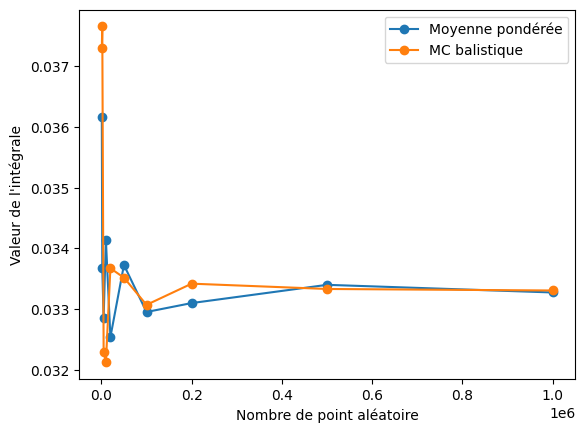

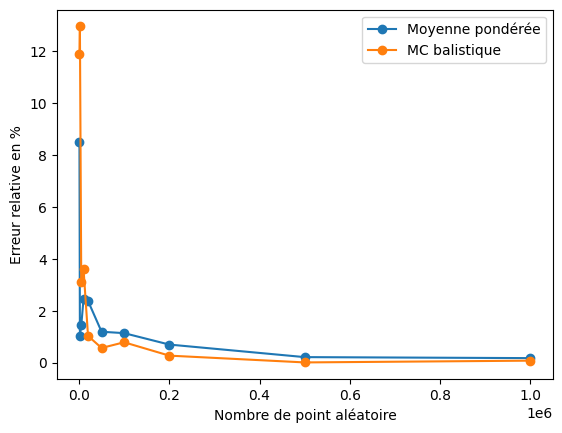

In [47]:
def Int_Moyenne_Pondérée(f,f_theo,params):
    a,b,N=params

    Int_theo=f_theo(b)-f_theo(a)
    x=rng.uniform(a,b,N)
    y=f(x)
    Int=np.mean(y)*(b-a)
    err=abs(1-(Int/Int_theo))*100

    return Int,err

def MC_balistique(f,f_theo,params): #f est la fonction, params est une liste de la forme [a,b,N] où a et b sont les bornes de l'intervalle d'intégration et N est le nombre de points à générer
    a=params[0]
    b=params[1]
    N=params[2]

    Int_theo=f_theo(b)-f_theo(a)

    x_boite=np.linspace(a,b,N)
    y_boite=f(x_boite)

    M_haut=y_boite.max()

    if M_haut>0:
        M_haut*=1.05
        
    elif M_haut<0:
        M_haut*=0
    
    M_bas=y_boite.min()

    if M_bas>0:
        M_bas*=0

    elif M_bas<0:
        M_bas*=1.05

    x=rng.uniform(a,b,N)
    y=rng.uniform(M_bas,M_haut,N)

    points_in_posi=(f(x)>=0) & (y>=0) & (y<f(x))#On récupère tous les points qui sont dans la région positive à intégrer
    points_in_néga=(f(x)<=0) & (y<=0) & (y>f(x))

    points_in=points_in_posi.astype(int)-points_in_néga.astype(int) #On récupère tous les points qui sont dans la région à intégrer, en prenant en compte les régions négatives

    I=(b-a)*(M_haut-M_bas)*np.mean(points_in) #L'intégrale est données par le pourcentage de points dans la région fois l'aire de la boîte)

    err=abs(1-(I/Int_theo))*100 #On calcule l'erreur en pourcentage
    return I,err

fonction = lambda x: np.exp(-3*x)*(np.sin(x)**3) #Fonction qui prend x en entrée et retourne la valeur de la fonction à ce point
f_theo=lambda x:np.exp(-3*x)*(-27*np.sin(x)+5*np.sin(3*x)-9*np.cos(x)+5*np.cos(3*x))/120

paramètres=[0,10,[1000,2000,5000,10000,20000,50000,100000,200000,500000,1000000]]

Int_pond_list=[]
yerr_pond_list=[]

Int_bal_list=[]
yerr_bal_list=[]

for N in paramètres[2]:
    paramètres_temp=[paramètres[0],paramètres[1],N]
    Int_pond,yerr_pond=Int_Moyenne_Pondérée(fonction,f_theo,paramètres_temp)
    Int_bal,yerr_bal=MC_balistique(fonction,f_theo,paramètres_temp)
    
    Int_pond_list.append(Int_pond)
    yerr_pond_list.append(yerr_pond)
    
    Int_bal_list.append(Int_bal)
    yerr_bal_list.append(yerr_bal)

plt.figure()
plt.plot(paramètres[2],Int_pond_list,label='Moyenne pondérée',marker='o')
plt.plot(paramètres[2],Int_bal_list,label='MC balistique',marker='o')
plt.ylabel("Valeur de l'intégrale")
plt.xlabel("Nombre de point aléatoire")
plt.savefig("Intégrale_2.png")
plt.legend()

plt.figure()
plt.plot(paramètres[2],yerr_pond_list,label='Moyenne pondérée',marker='o')
plt.plot(paramètres[2],yerr_bal_list,label='MC balistique',marker='o')
plt.ylabel("Erreur relative en %")
plt.xlabel("Nombre de point aléatoire")
plt.legend()
plt.savefig("Erreur_2.png")
plt.show()


## 4.

La pente de la courbe de l'erreur du MC Balistique est = -0.5014367187717187
La pente de la courbe de l'erreur du la Moyenne pondérée est = -0.5056915589941331


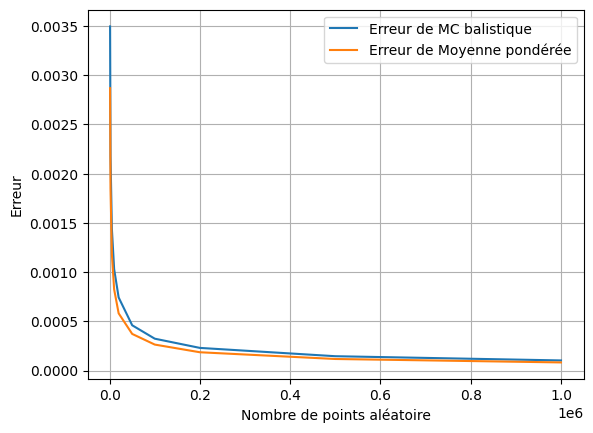

In [ ]:
def Int_Moyenne_Pondérée_erreur(f,params):
    a,b,N=params

    x=rng.uniform(a,b,N)
    y=f(x)

    variance=np.mean(y**2)-np.mean(y)**2

    erreur = (b - a) * np.sqrt(variance/N)

    return erreur 

def MC_balistique_erreur(f,params): #f est la fonction, params est une liste de la forme [a,b,N] où a et b sont les bornes de l'intervalle d'intégration et N est le nombre de points à générer
    a=params[0]
    b=params[1]
    N=params[2]

    x_boite=np.linspace(a,b,N)
    y_boite=f(x_boite)

    M_bas=1.05*np.min(y_boite)
    M_haut=1.05*np.max(y_boite)

    x=rng.uniform(a,b,N)
    y=rng.uniform(M_bas,M_haut,N)

    fx=f(x)

    points_in_posi=(fx>=0) & (y>=0) & (y<fx)#On récupère tous les points qui sont dans la région positive à intégrer en boolean
    points_in_néga=(fx<=0) & (y<=0) & (y>fx)

    points_in=points_in_posi.astype(int)-points_in_néga.astype(int) #On récupère tous les points qui sont dans la région à intégrer, en prenant en compte les régions négatives. True=1 et False=0
    
    variance = np.mean(points_in**2)-np.mean(points_in)**2

    erreur = (b-a)*(M_haut-M_bas)*np.sqrt(variance/N)
    return erreur

paramètres=[0,10,[1000,2000,5000,10000,20000,50000,100000,200000,500000,1000000]]

erreur_bal=[]
erreur_Moy=[]

fonction = lambda x: np.exp(-3*x)*(np.sin(x)**3) #Fonction qui prend x en entrée et retourne la valeur de la fonction à ce point

for N in paramètres[3]:
    paramètres_temp=[paramètres[0],paramètres[1],N]

    err_bal = MC_balistique_erreur(fonction, paramètres_temp)
    erreur_bal.append(err_bal)

    err_Moy=Int_Moyenne_Pondérée_erreur(fonction,paramètres_temp)
    erreur_Moy.append(err_Moy)

pente_bal=np.polyfit(np.log(paramètres[2]),np.log(erreur_bal),deg=1)
pente_Moy=np.polyfit(np.log(paramètres[2]),np.log(erreur_Moy),deg=1)

print("La pente de la courbe de l'erreur du MC Balistique est =",pente_bal[0])
print("La pente de la courbe de l'erreur du la Moyenne pondérée est =",pente_Moy[0])

plt.figure()
plt.plot(paramètres[2],erreur_bal,label="Erreur de MC balistique")
plt.plot(paramètres[2],erreur_Moy,label="Erreur de Moyenne pondérée")
plt.xlabel("Nombre de points aléatoire")
plt.ylabel("Erreur")
plt.legend()
plt.grid(which="both")
plt.savefig("Erreur.png")
plt.show()

## 5.

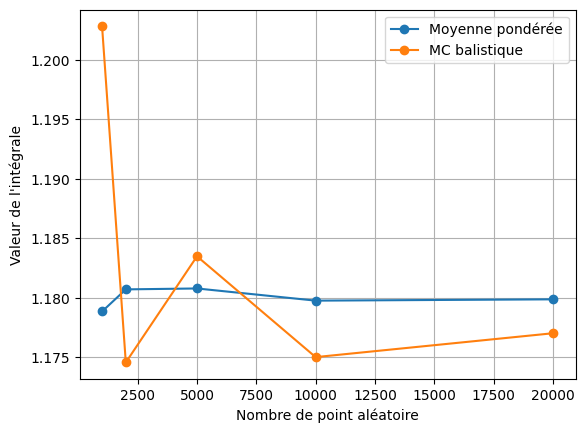

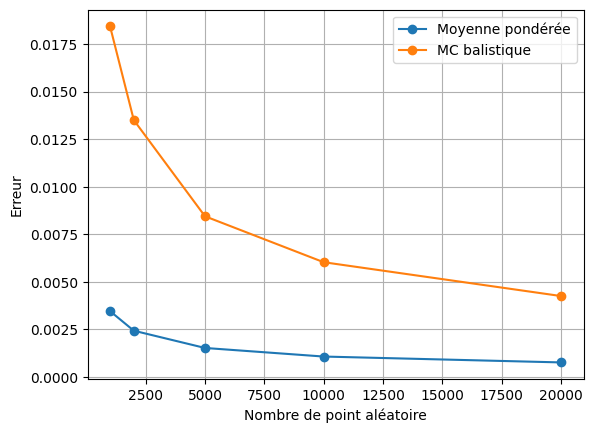

In [49]:
def MC_balistique_3D(f,params):
    ax,bx,ay,by,N=params #Params doit être de la forme [ax,bx,ay,by,N]. ax et bx sont les bornes en x, ay et by sont les bornes en y et N est le nombre de points aléatoires

    x=rng.uniform(ax,bx,N)
    y=rng.uniform(ay,by,N)
    
    fxy=f(x,y)

    x_boîte=np.linspace(ax,bx,N)
    y_boîte=np.linspace(ay,by,N)
    x_grille,y_grille=np.meshgrid(x_boîte,y_boîte)

    z_boîte=f(x_grille,y_grille)

    M_haut=z_boîte.max()

    if M_haut>0:
        M_haut*=1.05
        
    elif M_haut<0:
        M_haut*=0
    
    M_bas=z_boîte.min()

    if M_bas>0:
        M_bas*=0

    elif M_bas<0:
        M_bas*=1.05

    z=rng.uniform(M_bas,M_haut,N)

    points_in_posi=(fxy>=0) & (z>=0) & (z<fxy)
    points_in_nega=(fxy<=0) & (z<=0) & (z>fxy)

    points_in=points_in_posi.astype(int) - points_in_nega.astype(int)

    I = (bx-ax)*(by-ay)*(M_haut-M_bas)*np.mean(points_in)
    
    variance = np.mean(points_in**2)-np.mean(points_in)**2

    erreur = (bx-ax)*(M_haut-M_bas)*(by-ay)*np.sqrt(variance/N)

    return I,erreur

def Moyenne_pondérée_3D(f,params):
    ax,bx,ay,by,N=params

    x=rng.uniform(ax,bx,N)
    y=rng.uniform(ay,by,N)
    fxy=f(x,y)

    I=(bx-ax)*(by-ay)*np.mean(fxy)
    
    variance=np.mean(fxy**2)-np.mean(fxy)**2

    erreur = (bx-ax)*(by-ay)*np.sqrt(variance/N)

    return I, erreur

fonction = lambda x,y:np.sqrt(1+x*np.exp(-y**3)) 
paramètres=[0,1,0,1,[1000,2000,5000,10_000,20_000]]

erreur_bal=[]
erreur_Moy=[]

Int_Moy_liste=[]
Int_bal_liste=[]

for N in paramètres[4]:
    paramètres_temp=[paramètres[0],paramètres[1],paramètres[2],paramètres[3],N]

    Int_bal,err_bal = MC_balistique_3D(fonction, paramètres_temp)
    erreur_bal.append(err_bal)
    Int_bal_liste.append(Int_bal)

    Int_Moy,err_Moy=Moyenne_pondérée_3D(fonction,paramètres_temp)
    erreur_Moy.append(err_Moy)
    Int_Moy_liste.append(Int_Moy)
    

plt.figure()
plt.plot(paramètres[4],Int_Moy_liste,label='Moyenne pondérée',marker='o')
plt.plot(paramètres[4],Int_bal_liste,label='MC balistique',marker='o')
plt.ylabel("Valeur de l'intégrale")
plt.xlabel("Nombre de point aléatoire")
plt.legend()
plt.grid(which="both")
plt.savefig("Intégrale 3D.png")

plt.figure()
plt.plot(paramètres[4],erreur_Moy,label='Moyenne pondérée',marker='o')
plt.plot(paramètres[4],erreur_bal,label='MC balistique',marker='o')
plt.ylabel("Erreur")
plt.xlabel("Nombre de point aléatoire")
plt.legend()
plt.grid(which="both")
plt.savefig("Erreur 3D.png")
plt.show()


### Vérification

In [11]:
def MC_balistique_3D(f,params):
    ax,bx,ay,by,N=params #Params doit être de la forme [ax,bx,ay,by,N]. ax et bx sont les bornes en x, ay et by sont les bornes en y et N est le nombre de points aléatoires

    x=rng.uniform(ax,bx,N)
    y=rng.uniform(ay,by,N)
    
    fxy=f(x,y)

    x_boîte=np.linspace(ax,bx,N)
    y_boîte=np.linspace(ay,by,N)
    x_grille,y_grille=np.meshgrid(x_boîte,y_boîte)

    z_boîte=f(x_grille,y_grille)

    M_haut=z_boîte.max()

    if M_haut>0:
        M_haut*=1.05
        
    elif M_haut<0:
        M_haut*=0
    
    M_bas=z_boîte.min()

    if M_bas>0:
        M_bas*=0

    elif M_bas<0:
        M_bas*=1.05

    z=rng.uniform(M_bas,M_haut,N)

    points_in_posi=(fxy>=0) & (z>=0) & (z<fxy)
    points_in_nega=(fxy<=0) & (z<=0) & (z>fxy)

    points_in=points_in_posi.astype(int) - points_in_nega.astype(int)

    I = (bx-ax)*(by-ay)*(M_haut-M_bas)*np.mean(points_in)
    
    variance = np.mean(points_in**2)-np.mean(points_in)**2

    erreur = (bx-ax)*(M_haut-M_bas)*(by-ay)*np.sqrt(variance/N)

    return I,erreur

def Moyenne_pondérée_3D(f,params):
    ax,bx,ay,by,N=params

    x=rng.uniform(ax,bx,N)
    y=rng.uniform(ay,by,N)
    fxy=f(x,y)

    I=(bx-ax)*(by-ay)*np.mean(fxy)
    
    variance=np.mean(y**2)-np.mean(y)**2

    erreur = (bx-ax)*(by-ay)*np.sqrt(variance/N)

    return I, erreur

fonction = lambda x,y:x+y #L'intégrale de (x+y) entre x et y entre 0 et 1 est 1
paramètres=[0,1,0,1,10000]  

Int_MC,err_MC=MC_balistique_3D(fonction,paramètres)
Int_Moy,err_Moy=Moyenne_pondérée_3D(fonction,paramètres)
print("Intégrale par MC =",Int_MC)
print("Intégrale par moyenne pondérée =",Int_Moy)

Intégrale par MC = 1.0101
Intégrale par moyenne pondérée = 1.0079401047583272


## 6.

In [26]:
#On va faire l'intégrale par importance sampling pour voir si on peut faire mieux que les deux méthodes précédentes

        
def Échantillon_pondéré(f,N): #Fonction créée sur mesure pour le problème 
    g= lambda x: np.sqrt(1+x) #Fonction approximée
    
    Z_g=2/3*(2*np.sqrt(2)-1) #On trouve l'évidence pour normaliser en x = 0 et x = 1

    u=rng.uniform(0,1,N)
    x=(1+3*Z_g*u/2)**(2/3)-1 #On intègre g(x)/Z_g pour obtenir la fonction de répartition qui est une distribution uniforme (u) et on isole x qui est une distribution biaisée
    y=rng.uniform(0,1,N)
    p=g(x)/Z_g #Fonction normalisée

    weight=f(x,y)/p #Poids de la fonction

    I=np.mean(weight)

    variance = np.mean(weight**2)-np.mean(weight)**2
    erreur=np.sqrt(variance/N)
    return I,erreur

fonction = lambda x,y:np.sqrt(1+x*np.exp(-y**3)) 

Int,err=importance_mc(fonction, 1000000)
print(f"L'intégrale est = {Int:.5f} +/- {err:.5f}")



L'intégrale est = 1.17974 +/- 0.00005


### Comparaison des erreurs

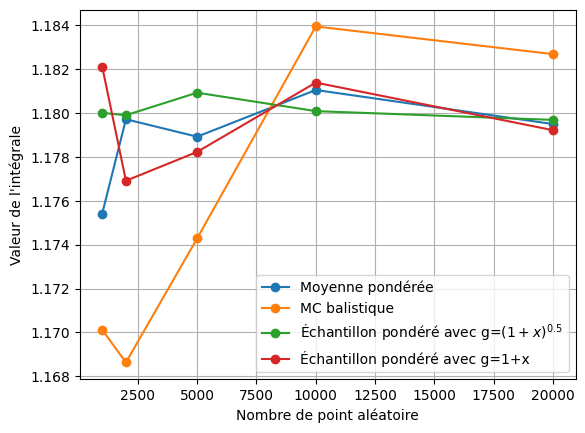

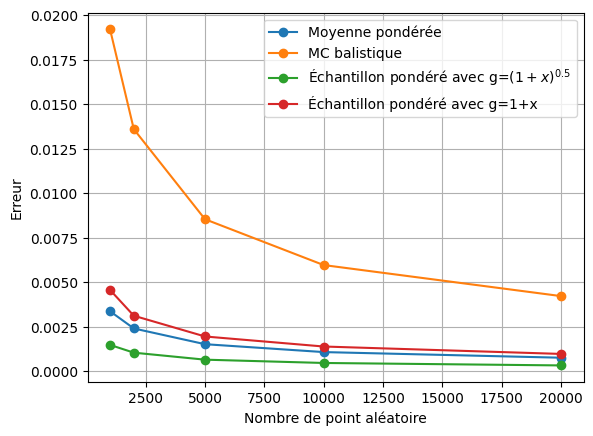

In [54]:
def MC_balistique_3D(f,params):
    ax,bx,ay,by,N=params #Params doit être de la forme [ax,bx,ay,by,N]. ax et bx sont les bornes en x, ay et by sont les bornes en y et N est le nombre de points aléatoires

    x=rng.uniform(ax,bx,N)
    y=rng.uniform(ay,by,N)
    
    fxy=f(x,y)

    x_boîte=np.linspace(ax,bx,N)
    y_boîte=np.linspace(ay,by,N)
    x_grille,y_grille=np.meshgrid(x_boîte,y_boîte)

    z_boîte=f(x_grille,y_grille)

    M_haut=z_boîte.max()

    if M_haut>0:
        M_haut*=1.05
        
    elif M_haut<0:
        M_haut*=0
    
    M_bas=z_boîte.min()

    if M_bas>0:
        M_bas*=0

    elif M_bas<0:
        M_bas*=1.05

    z=rng.uniform(M_bas,M_haut,N)

    points_in_posi=(fxy>=0) & (z>=0) & (z<fxy)
    points_in_nega=(fxy<=0) & (z<=0) & (z>fxy)

    points_in=points_in_posi.astype(int) - points_in_nega.astype(int)

    I = (bx-ax)*(by-ay)*(M_haut-M_bas)*np.mean(points_in)
    
    variance = np.mean(points_in**2)-np.mean(points_in)**2

    erreur = (bx-ax)*(M_haut-M_bas)*(by-ay)*np.sqrt(variance/N)

    return I,erreur

def Moyenne_pondérée_3D(f,params):
    ax,bx,ay,by,N=params

    x=rng.uniform(ax,bx,N)
    y=rng.uniform(ay,by,N)
    fxy=f(x,y)

    I=(bx-ax)*(by-ay)*np.mean(fxy)
    
    variance=np.mean(fxy**2)-np.mean(fxy)**2

    erreur = (bx-ax)*(by-ay)*np.sqrt(variance/N)

    return I, erreur

def Échantillon_pondéré(f,N): #Fonction créée sur mesure pour le problème 
    g= lambda x: np.sqrt(1+x) #Fonction approximée
    
    Z_g=2/3*(2*np.sqrt(2)-1) #On trouve l'évidence pour normaliser en x = 0 et x = 1

    u=rng.uniform(0,1,N)
    x=(1+3*Z_g*u/2)**(2/3)-1 #On intègre g(x)/Z_g pour obtenir la fonction de répartition qui est une distribution uniforme (u) et on isole x qui est une distribution biaisée
    y=rng.uniform(0,1,N) #y est uniforme puisque son poids est beaucoup plus faible que x
    p=g(x)/Z_g #Fonction normalisée

    weight=f(x,y)/p #Poids de la fonction

    I=np.mean(weight)

    variance = np.mean(weight**2)-np.mean(weight)**2
    erreur=np.sqrt(variance/N)
    return I,erreur

def Échantillon_pondéré_2(f,N): #On prend un autre g pour tester la différence d'approximation sur le calcul de l'intégrale
    g = lambda x: 1+x

    Z_g=3/2

    u=rng.uniform(0,1,N)

    x=np.sqrt(1+3*u)-1
    y=rng.uniform(0,1,N)

    p=g(x)/Z_g

    weight=f(x,y)/p

    I=np.mean(weight)

    variance = np.mean(weight**2)-np.mean(weight)**2
    erreur=np.sqrt(variance/N)

    return I,erreur
fonction = lambda x,y:np.sqrt(1+x*np.exp(-y**3)) 
paramètres=[0,1,0,1,[1000,2000,5000,10_000,20_000]]

erreur_bal=[]
erreur_Moy=[]
erreur_Ech=[]
erreur_Ech2=[]

Int_Moy_liste=[]
Int_bal_liste=[]
Int_Ech_liste=[]
Int_Ech2_liste=[]

for N in paramètres[4]: #Boucle pour calculer les intégrales pour chaque valeur de N
    paramètres_temp=[paramètres[0],paramètres[1],paramètres[2],paramètres[3],N]

    Int_bal,err_bal = MC_balistique_3D(fonction, paramètres_temp)
    erreur_bal.append(err_bal)
    Int_bal_liste.append(Int_bal)

    Int_Moy,err_Moy=Moyenne_pondérée_3D(fonction,paramètres_temp)
    erreur_Moy.append(err_Moy)
    Int_Moy_liste.append(Int_Moy)

    Int_Ech,err_Ech=Échantillon_pondéré(fonction,N)
    erreur_Ech.append(err_Ech)
    Int_Ech_liste.append(Int_Ech)

    Int_Ech2,err_Ech2=Échantillon_pondéré_2(fonction,N)
    erreur_Ech2.append(err_Ech2)
    Int_Ech2_liste.append(Int_Ech2)
    

plt.figure()
plt.plot(paramètres[4],Int_Moy_liste,label='Moyenne pondérée',marker='o')
plt.plot(paramètres[4],Int_bal_liste,label='MC balistique',marker='o')
plt.plot(paramètres[4],Int_Ech_liste,label='Échantillon pondéré avec g=$(1+x)^{0.5}$',marker='o')
plt.plot(paramètres[4],Int_Ech2_liste,label='Échantillon pondéré avec g=1+x',marker='o')
plt.ylabel("Valeur de l'intégrale")
plt.xlabel("Nombre de point aléatoire")
plt.legend()
plt.grid(which="both")
plt.savefig("Intégrale 3D_échantillon_pondéré.png")

plt.figure()
plt.plot(paramètres[4],erreur_Moy,label='Moyenne pondérée',marker='o')
plt.plot(paramètres[4],erreur_bal,label='MC balistique',marker='o')
plt.plot(paramètres[4],erreur_Ech,label='Échantillon pondéré avec g=$(1+x)^{0.5}$',marker='o')
plt.plot(paramètres[4],erreur_Ech2,label='Échantillon pondéré avec g=1+x',marker='o')
plt.ylabel("Erreur")
plt.xlabel("Nombre de point aléatoire")
plt.legend()
plt.grid(which="both")
plt.savefig("Erreur 3D_échantillon_pondéré.png")
plt.show()


# Question 3

## 1.

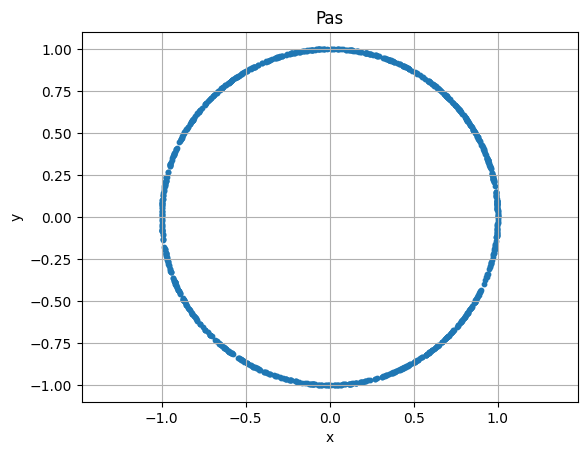

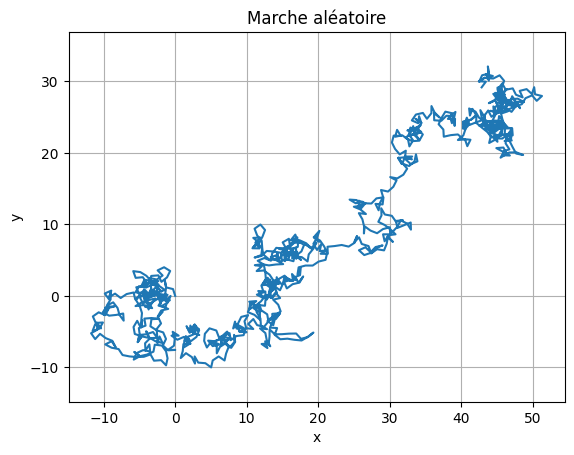

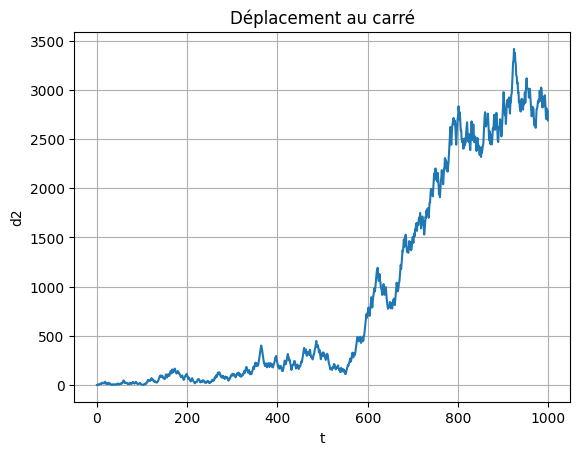

In [ ]:
import time
import numpy as np
import matplotlib.pyplot as plt

seed = int(time.time())
rng = np.random.default_rng(seed)

#-------------------------Récupération des morceaux de code des notes de cours sous forme de fonctions----------------------------
def pas(rng):
    while True:
        x = rng.uniform(-1, 1)
        y = rng.uniform(-1, 1)
        global r2
        r2 = x*x + y*y
        if r2 <= 0.25:
            break

    r = np.sqrt(r2)
    x /= r
    y /= r
    return x, y

def marche_aleatoire_l(nombre_marcheurs,nombre_pas,rng):
    x_marcheurs = []
    y_marcheurs = []
    px_marcheurs = []
    py_marcheurs = []
    d2_marcheurs = []
    for marcheur in range(nombre_marcheurs):
        x = [0.0]
        y = [0.0]
        d2 = [0.0]
        px = []
        py = []
        # Boucle de marche aléatoire
        for i in range(1, nombre_pas):  # 1..999 => total 1000 points
            dx, dy = pas(rng)
            px.append(dx)
            py.append(dy)

            xi = x[-1] + dx
            yi = y[-1] + dy
            d2i = xi*xi + yi*yi

            x.append(xi)
            y.append(yi)
            d2.append(d2i)
        x_marcheurs.append(x)
        y_marcheurs.append(y)
        px_marcheurs.append(px)
        py_marcheurs.append(py)
        d2_marcheurs.append(d2)
    return x_marcheurs, y_marcheurs, px_marcheurs, py_marcheurs, d2_marcheurs
#------------------------------Méthode principale------------------------------
nombre_marcheurs=1000 #Plus le nombre de marcheurs est élevé, plus les résultats seront précis, mais cela prendra plus de temps à s'exécuter
nombre_pas=1000
x,y,px,py,d2=marche_aleatoire_l(nombre_marcheurs,nombre_pas,rng)#Le résultat est une liste contenant les listes des positions x, y, des pas px, py et des distances au carré d2 pour chaque marcheur

#Traçage des résultats pour le 1er marcheur (Tester que la traduction Julia-Python s'est bien fait)
n=2 #On choisit le 1er marcheur (n-1=0) pour les tracés suivants
plt.figure()
plt.scatter(px[n-1], py[n-1], s=10)
plt.title("Pas")
plt.xlabel("x")
plt.ylabel("y")
plt.axis("equal")
plt.grid(True)R

plt.figure()
plt.plot(x[n-1], y[n-1])
plt.title("Marche aléatoire")
plt.xlabel("x")
plt.ylabel("y")
plt.axis("equal")
plt.grid(True)

plt.figure()
plt.plot(d2[n-1])
plt.title("Déplacement au carré")
plt.xlabel("t")
plt.ylabel("d2")
plt.grid(True)

plt.show()



## 2.

Valeurs des moyennes: [30.34352926 28.75375963 28.23275121 28.06096114] ± [5.51732047 1.35101853 0.4867322  0.32272076]
Valeurs des variances: [304.40825119 182.5251056  236.90823075 208.29737609]


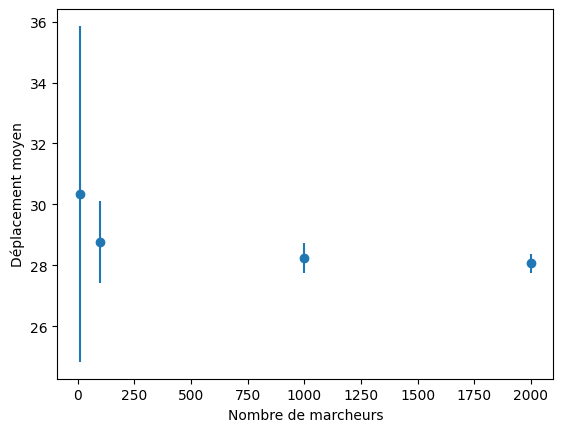

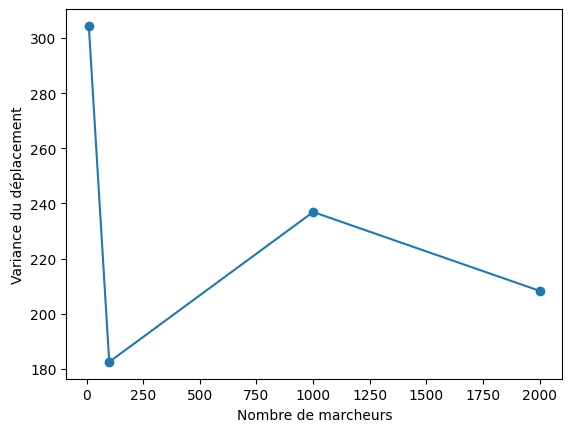

In [21]:
import time
import numpy as np
import matplotlib.pyplot as plt

seed = int(time.time())
rng = np.random.default_rng(seed)

#-------------------------Récupération des morceaux de code des 
# notes de cours sous forme de fonctions----------------------------
def pas(rng):
    while True:
        x = rng.uniform(-1, 1)
        y = rng.uniform(-1, 1)
        global r2
        r2 = x*x + y*y
        if r2 <= 0.25:
            break

    r = np.sqrt(r2)
    x /= r
    y /= r
    return x, y

def marche_aleatoire_l(nombre_marcheurs,nombre_pas,rng):
    x_marcheurs = []
    y_marcheurs = []
    px_marcheurs = []
    py_marcheurs = []
    d2_marcheurs = []
    for marcheur in range(nombre_marcheurs):
        x = [0.0]
        y = [0.0]
        d2 = [0.0]
        px = []
        py = []
        # Boucle de marche aléatoire
        for i in range(1, nombre_pas):  # 1..999 => total 1000 pas
            dx, dy = pas(rng)
            px.append(dx)
            py.append(dy)

            xi = x[-1] + dx
            yi = y[-1] + dy
            d2i = xi*xi + yi*yi

            x.append(xi)
            y.append(yi)
            d2.append(d2i)
        x_marcheurs.append(x)
        y_marcheurs.append(y)
        px_marcheurs.append(px)
        py_marcheurs.append(py)
        d2_marcheurs.append(d2)
    return x_marcheurs, y_marcheurs, px_marcheurs, py_marcheurs, d2_marcheurs
#------------------------------Méthode principale------------------------------
nombre_marcheurs=[10,100,1000,2000]
d_moyen = np.zeros(len(nombre_marcheurs))
d2_moyen = np.zeros(len(nombre_marcheurs))

nombre_pas=1000

for i, n in enumerate(nombre_marcheurs):
    _,_,_,_,d2=marche_aleatoire_l(n,nombre_pas,rng)
    d2_final = [d[-1] for d in d2]
    d_moyen[i] = np.mean(np.sqrt(d2_final))
    d2_moyen[i] = np.mean(d2_final)

var=d2_moyen - d_moyen**2
stdr=np.sqrt(var)/np.sqrt(nombre_marcheurs)
print("Valeurs des moyennes:", d_moyen,'±',stdr)
print("Valeurs des variances:", var)
#---------------------Affichage des moyennes-----------------------
plt.figure()
plt.errorbar(nombre_marcheurs, d_moyen, yerr=stdr, marker='o',linestyle=' ')
plt.xlabel('Nombre de marcheurs')
plt.ylabel('Déplacement moyen')
plt.savefig("Déplacement moyen 3")
plt.show()

plt.figure()
plt.plot(nombre_marcheurs, var, marker='o')
plt.xlabel('Nombre de marcheurs')
plt.ylabel('Variance du déplacement')
plt.savefig("Variance 3")

plt.show()



